## Load the tokenizer

In [9]:
import sys
sys.path.insert(0, "/content/personalize_chatbot")

In [ ]:
from minbpe import BasicTokenizer

tokenizer = BasicTokenizer()
tokenizer.load(model_file="/content/personalize_chatbot/output/tokenizer/my_tokenizer.model")


def get_vocab_size(tokenizer: BasicTokenizer) -> int:
    vocab = tokenizer.vocab
    special_tokens = tokenizer.special_tokens

    return len(vocab) + len(special_tokens)

FileNotFoundError: [Errno 2] No such file or directory: '../output/tokenizer/my_tokenizer.model'

## Create the model

In [5]:
import torch
torch.manual_seed(3647)

In [ ]:
from transformer.model import GPTLanguageModel

block_size = 64
n_embd = 128
n_head = 8
n_layer = 1
dropout = 0.2
batch_size = 64
vocab_size = get_vocab_size(tokenizer)
device = 'cuda' if torch.cuda.is_available() else 'cpu'

model = GPTLanguageModel(
    vocab_size=vocab_size,
    block_size=block_size,
    n_embd=n_embd,
    n_head=n_head,
    n_layer=n_layer,
    dropout=dropout,
    device=device
).to(device)
model = torch.compile(model)

print(sum(p.numel() for p in model.parameters())/1e6, 'M parameters')

ModuleNotFoundError: No module named 'transformer'

In [7]:
import os, sys, pathlib, glob
print("CWD:", os.getcwd())
print("Python:", sys.version)
print("First few sys.path entries:", sys.path[:5])
print("Does mbipi exist here?", glob.glob("**/mbipi*", recursive=True)[:10])


CWD: /content
Python: 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
First few sys.path entries: ['/content', '/env/python', '/usr/lib/python312.zip', '/usr/lib/python3.12', '/usr/lib/python3.12/lib-dynload']
Does mbipi exist here? []


## Data preparation

### 1. Load the data

In [23]:
with open("../output/combined_text.txt", "r", encoding='utf-8') as f:
    text_sequence = f.read()

encoded_text_sequence = tokenizer.encode(text_sequence)
len(encoded_text_sequence)

95379

### 2. Split it into train and test

In [24]:
data = torch.tensor(encoded_text_sequence, dtype=torch.long)
split_index = int(0.9 * len(data))
train_data = data[:split_index]
val_data = data[split_index:]

### 3. Data loader

In [25]:
from typing import Tuple
from torch.utils.data import Dataset, DataLoader


class TextDataset(Dataset):
    def __init__(self, data: torch.Tensor, block_size: int) -> None:
        if len(data) <= block_size:
            raise ValueError(
                f"The length of the data ({len(data)}) must be greater than the block_size ({block_size})."
            )

        self.data = data
        self.block_size = block_size

    def __len__(self) -> int:
        return len(self.data) - self.block_size

    def __getitem__(self, index: int) -> Tuple[torch.Tensor, torch.Tensor]:
        x = self.data[index : index + self.block_size]
        y = self.data[index + 1 : index + self.block_size + 1]
        return x, y


def get_dataloaders(
    train_data: torch.Tensor,
    val_data: torch.Tensor,
    block_size: int,
    batch_size: int,
    device: torch.device,
) -> Tuple[DataLoader, DataLoader]:
    train_dataset = TextDataset(train_data.to(device), block_size)
    val_dataset = TextDataset(val_data.to(device), block_size)

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
    )
    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
    )

    return train_loader, val_loader

In [26]:
train_loader, val_loader = get_dataloaders(
    train_data=train_data,
    val_data=val_data,
    block_size=block_size,
    batch_size=batch_size,
    device=device,
)
x, y = next(iter(train_loader))
x.shape, y.shape

(torch.Size([64, 64]), torch.Size([64, 64]))

### 4. Training

In [27]:
from typing import Dict


@torch.no_grad()
def estimate_loss(
    model: torch.nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    eval_iters: int
) -> Dict[str, float]:
    output = {}
    model.eval()

    for split, loader in [('train', train_loader), ('val', val_loader)]:
        losses = torch.zeros(eval_iters)
        for i, (x, y) in enumerate(loader):
            if i >= eval_iters:
                break
            with torch.no_grad():
                _, loss = model(x, y)
            losses[i] = loss.item()
        output[split] = losses.mean().item()

    model.train()
    return output

In [28]:
def save_checkpoint(
    model: GPTLanguageModel,
    optimizer: torch.optim.Optimizer,
    epoch: int,
    loss: float,
    file_path: str = "checkpoint.pth"
) -> None:
    checkpoint = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'loss': loss
    }
    torch.save(checkpoint, file_path)

In [35]:
import torch._dynamo
torch._dynamo.config.suppress_errors = True

max_iters = 1
eval_interval = 100
eval_iters = 200
learning_rate = 3e-4

optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)
train_loader, val_loader = get_dataloaders(
    train_data=train_data,
    val_data=val_data,
    block_size=block_size,
    batch_size=batch_size,
    device=device
)

train_losses = []
val_losses = []

for iteration in range(max_iters):
    for batch_idx, (x_batch, y_batch) in enumerate(train_loader):
        # Evaluation
        if batch_idx % eval_interval == 0 or batch_idx == len(train_loader) - 1:
            losses = estimate_loss(
                model=model,
                train_loader=train_loader,
                val_loader=val_loader,
                eval_iters=min(eval_iters, len(val_loader))
            )
            train_losses.append(losses['train'])
            val_losses.append(losses['val'])

            print(
                f"iteration {iteration} / step {batch_idx}: "
                f"train loss {losses['train']:.4f}, "
                f"val loss {losses['val']:.4f}"
            )

        # Training step
        logits, loss = model(x_batch, y_batch)
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()

    # Save checkpoint
    save_checkpoint(
        model=model,
        optimizer=optimizer,
        epoch=iteration,
        loss=loss.item(),
        file_path=f"../output/pre_training/run_4/checkpoint_{iteration}.pth"
    )

iteration 0 / step 0: train loss 1.8832, val loss 1.7469
iteration 0 / step 100: train loss 1.8435, val loss 1.7344
iteration 0 / step 200: train loss 1.8052, val loss 1.7234
iteration 0 / step 300: train loss 1.7688, val loss 1.7148
iteration 0 / step 400: train loss 1.7314, val loss 1.7125
iteration 0 / step 500: train loss 1.6978, val loss 1.7067
iteration 0 / step 600: train loss 1.6688, val loss 1.7021
iteration 0 / step 700: train loss 1.6411, val loss 1.7176
iteration 0 / step 800: train loss 1.6219, val loss 1.7122
iteration 0 / step 900: train loss 1.5916, val loss 1.6989
iteration 0 / step 1000: train loss 1.5690, val loss 1.7145
iteration 0 / step 1100: train loss 1.5420, val loss 1.7236
iteration 0 / step 1200: train loss 1.5185, val loss 1.7166
iteration 0 / step 1300: train loss 1.4884, val loss 1.7137
iteration 0 / step 1340: train loss 1.4734, val loss 1.7226


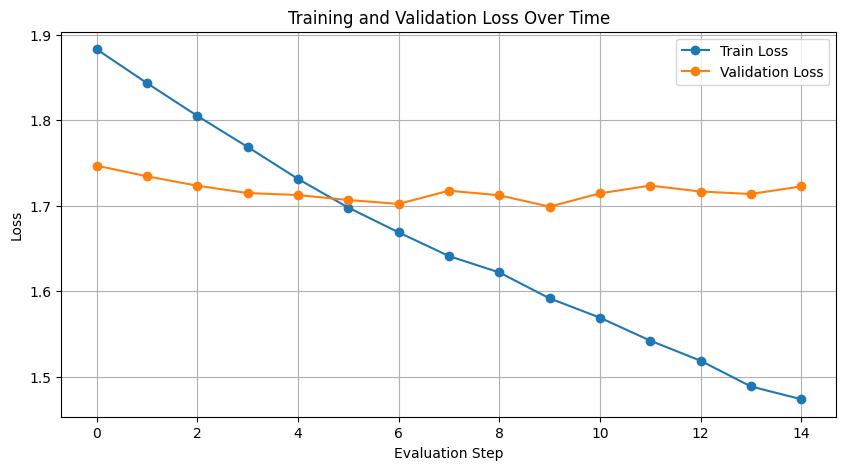

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(train_losses, label="Train Loss", marker='o')
plt.plot(val_losses, label="Validation Loss", marker='o')
plt.xlabel("Evaluation Step")
plt.ylabel("Loss")
plt.title("Training and Validation Loss Over Time")
plt.legend()
plt.grid()
plt.show()

In [37]:
input_tokens = tokenizer.encode("10 baja")
input_tokens = torch.tensor(
    input_tokens, dtype=torch.long).unsqueeze(0).to(device)

model.eval()
with torch.no_grad():
    output = model.generate(input_tokens=input_tokens, max_new_tokens=100)

print(tokenizer.decode(output[0].tolist()))

10 bajak no. Kisne cane Subject ho to bhej da Ma Ha sir sa satavite ha Kya Kitani tenga us k yrr kal jaAgi yrr le Ne bhi brr Kha sam kam sa vo toh chataana hai 32 Jinesh ko Kal college ho toh clg Ha Thodi der ha Kya Kuch bhi baar ulame to Mumhay ne cl
